
# Bidirectional-LSTM Model for Strudel code generation

# import statements

In [2]:
#import statements
import os
import re
import json
import pickle
import numpy as np
from collections import Counter
from pathlib import Path
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

# Preprocessing

In [2]:
# Tokenizer / Preprocessor for Strudel music files
class StrudelPreprocessor:
    def __init__(self, data_dir='StrudelOutput'):
        self.data_dir = data_dir
        self.vocabulary = {}        # Maps tokens to indices
        self.reverse_vocab = {}     # Maps indices back to tokens
        self.token_counts = Counter()  # Counts occurrences of each token
        
    # Parse a single Strudel file
    def parse_strudel_file(self, filepath):
        with open(filepath, 'r', encoding='utf-8') as f:
            content = f.read()
        
        # Extract CPM (characters per minute) if present
        cpm_match = re.search(r'setcpm\(([\d./]+)\)', content)
        cpm = cpm_match.group(1) if cpm_match else None
        
        # Extract all note blocks
        note_blocks = []
        note_pattern = r'\$:\s*note\(`<([^>]+)>`\)'
        for match in re.finditer(note_pattern, content, re.DOTALL):
            note_content = match.group(1).strip()
            lines = [line.strip() for line in note_content.split('\n') if line.strip()]
            note_blocks.append(lines)
        
        return {
            'cpm': cpm,
            'note_blocks': note_blocks,
            'filepath': filepath
        }
    
    # Tokenize a single musical element
    def tokenize_musical_element(self, element):
        element = element.strip()
        
        if not element or element == '-':  # Empty element or rest
            return ['-']
        
        if element.startswith('[') and element.endswith(']') and ',' in element:
            return [element]  # Chords with commas treated as single token
        
        if element.startswith('[') and ',' not in element:  # Grouped notes
            inner = element[1:-1].strip()
            tokens = []
            for part in inner.split():
                tokens.extend(self.tokenize_musical_element(part))
            return ['['] + tokens + [']']
        
        return [element]  # Single note/rest
    
    # Tokenize a line of music
    def tokenize_line(self, line):
        tokens = []
        i = 0
        current_token = ''
        bracket_depth = 0
        
        while i < len(line):
            char = line[i]
            
            if char == '[':  # Start of bracketed group
                if current_token.strip():
                    tokens.extend(self.tokenize_musical_element(current_token.strip()))
                    current_token = ''
                current_token = '['
                bracket_depth = 1
                i += 1
                
                # Capture entire bracketed content
                while i < len(line) and bracket_depth > 0:
                    char = line[i]
                    current_token += char
                    if char == '[':
                        bracket_depth += 1
                    elif char == ']':
                        bracket_depth -= 1
                    i += 1
                
                tokens.append(current_token.strip())
                current_token = ''
                
            elif char in ' \t':  # Token separator
                if current_token.strip():
                    tokens.extend(self.tokenize_musical_element(current_token.strip()))
                    current_token = ''
                i += 1
            else:
                current_token += char
                i += 1
        
        if current_token.strip():
            tokens.extend(self.tokenize_musical_element(current_token.strip()))
        
        return tokens
    
    # Build vocabulary from all parsed files
    def build_vocabulary(self, all_files_data):
        # Add special tokens
        special_tokens = ['<PAD>', '<START>', '<END>', '<SEP>', '<CPM>']
        for token in special_tokens:
            self.token_counts[token] = 999999  # Ensure they are included
        
        # Count all tokens in dataset
        for file_data in all_files_data:
            if file_data['cpm']:
                self.token_counts[f"<CPM:{file_data['cpm']}>"] += 1
            
            for note_block in file_data['note_blocks']:
                for line in note_block:
                    tokens = self.tokenize_line(line)
                    for token in tokens:
                        self.token_counts[token] += 1
        
        # Keep top 5000 tokens for vocabulary
        vocab_items = self.token_counts.most_common(5000)
        self.vocabulary = {token: idx for idx, (token, _) in enumerate(vocab_items)}
        self.reverse_vocab = {idx: token for token, idx in self.vocabulary.items()}
        
        print(f"Vocabulary size: {len(self.vocabulary)}")
        return self.vocabulary
    
    # Create input-output sequences for training
    def create_training_sequences(self, all_files_data, seq_length=50):
        sequences = []
        
        for file_data in all_files_data:
            file_tokens = ['<START>']
            if file_data['cpm']:
                file_tokens.append(f"<CPM:{file_data['cpm']}>")
            
            for block_idx, note_block in enumerate(file_data['note_blocks']):
                if block_idx > 0:
                    file_tokens.append('<SEP>')
                
                for line_idx, line in enumerate(note_block):
                    line_tokens = self.tokenize_line(line)
                    file_tokens.extend(line_tokens)
                    if line_idx < len(note_block) - 1:
                        file_tokens.append('<END>')
            
            # Convert tokens to indices
            token_indices = []
            for token in file_tokens:
                token_indices.append(self.vocabulary.get(token, self.vocabulary.get('<PAD>', 0)))
            
            # Create sequences of length seq_length
            for i in range(len(token_indices) - seq_length):
                seq_in = token_indices[i:i+seq_length]
                seq_out = token_indices[i+1:i+seq_length+1]
                sequences.append((seq_in, seq_out))
        
        print(f"Created {len(sequences)} training sequences")
        return sequences
    
    # Process all files in the data directory
    def process_all_files(self, seq_length=50):
        txt_files = list(Path(self.data_dir).glob('*.txt'))
        
        if len(txt_files) == 0:
            print(f"WARNING: No .txt files found in {self.data_dir}")
            return None
        
        # Parse all files
        all_files_data = []
        for i, filepath in enumerate(txt_files):
            if i % 1000 == 0:
                print(f"Parsing file {i}/{len(txt_files)}")
            try:
                file_data = self.parse_strudel_file(filepath)
                all_files_data.append(file_data)
            except Exception as e:
                print(f"Error parsing {filepath}: {e}")
        
        print(f"Successfully parsed {len(all_files_data)} files")
        
        self.build_vocabulary(all_files_data)  # Build vocab
        sequences = self.create_training_sequences(all_files_data, seq_length)
        return sequences
    
    # Save sequences and vocabulary to disk
    def save_processed_data(self, sequences, output_dir='processed_data'):
        os.makedirs(output_dir, exist_ok=True)
        
        X = np.array([seq[0] for seq in sequences])
        y = np.array([seq[1] for seq in sequences])
        
        np.save(f'{output_dir}/X_train.npy', X)
        np.save(f'{output_dir}/y_train.npy', y)
        
        # Save vocab & reverse vocab
        with open(f'{output_dir}/vocabulary.json', 'w') as f:
            json.dump(self.vocabulary, f)
        with open(f'{output_dir}/reverse_vocab.json', 'w') as f:
            json.dump(self.reverse_vocab, f)
        with open(f'{output_dir}/token_counts.pkl', 'wb') as f:
            pickle.dump(self.token_counts, f)
        
        print(f"\nSaved in {output_dir}/")
        print(f"  - X_train.npy: {X.shape}")
        print(f"  - y_train.npy: {y.shape}")
        print(f"  - vocabulary.json: {len(self.vocabulary)} tokens")
        return X, y


if __name__ == "__main__":
    preprocessor = StrudelPreprocessor(data_dir='StrudelOutput')
    sequences = preprocessor.process_all_files(seq_length=50)
    if sequences:
        X, y = preprocessor.save_processed_data(sequences)
        print(f"Total sequences: {len(sequences)}")
        print(f"Vocabulary size: {len(preprocessor.vocabulary)}")
    else:
        print("\nPreprocessing failed")


Parsing file 0/10000
Parsing file 1000/10000
Parsing file 2000/10000
Parsing file 3000/10000
Parsing file 4000/10000
Parsing file 5000/10000
Parsing file 6000/10000
Parsing file 7000/10000
Parsing file 8000/10000
Parsing file 9000/10000
Successfully parsed 10000 files
Vocabulary size: 5000
Created 140834 training sequences

Saved in processed_data/
  - X_train.npy: (140834, 50)
  - y_train.npy: (140834, 50)
  - vocabulary.json: 5000 tokens
Total sequences: 140834
Vocabulary size: 5000


# model training

In [4]:
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

#Enable mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision enabled: float16")

#Config
class Config:
    # Data paths
    DATA_DIR = 'processed_data'
    MODEL_SAVE_PATH = 'strudel_model.keras'

    # Model hyperparameters
    VOCAB_SIZE = 5000
    EMBEDDING_DIM = 128
    LSTM_UNITS = 256
    DROPOUT_RATE = 0.2

    # Training hyperparameters
    BATCH_SIZE = 512
    EPOCHS = 20
    LEARNING_RATE = 0.002
    VALIDATION_SPLIT = 0.05
    TEST_SPLIT = 0.05

    # Generation parameters
    SEQUENCE_LENGTH = 50
    TEMPERATURE = 1.0

config = Config()

#Load processed data
X = np.load(f'{config.DATA_DIR}/X_train.npy')
y = np.load(f'{config.DATA_DIR}/y_train.npy')

with open(f'{config.DATA_DIR}/vocabulary.json', 'r') as f:
    vocabulary = json.load(f)

with open(f'{config.DATA_DIR}/reverse_vocab.json', 'r') as f:
    reverse_vocab = {int(k): v for k, v in json.load(f).items()}

print(f"Total sequences: {X.shape[0]}")
print(f"Vocabulary size: {len(vocabulary)}")

# Reshape y for training
y = y.reshape(y.shape[0], y.shape[1], 1)

#Shuffle and split into train/val/test
total_size = X.shape[0]
val_size = int(total_size * config.VALIDATION_SPLIT)
test_size = int(total_size * config.TEST_SPLIT)
train_size = total_size - val_size - test_size

indices = np.arange(total_size)
np.random.shuffle(indices)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

#Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(10000, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(config.BATCH_SIZE, drop_remainder=True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Training batches: ~{len(list(train_dataset))}")
print(f"Validation batches: ~{len(list(val_dataset))}")
print(f"Test batches: ~{len(list(test_dataset))}")

Mixed precision enabled: float16
Total sequences: 140834
Vocabulary size: 5000
Training batches: ~247
Validation batches: ~14
Test batches: ~14


Mixed precision enabled: float16
Total sequences: 140834
Vocabulary size: 5000
Training batches: ~247
Validation batches: ~14
Test batches: ~14


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 50, 128)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 50, 512)        │       788,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50, 256)        │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50, 5000)       │     1,285,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,844,808 (10.85 MB)

 Trainable params: 2,844,808 (10.85 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/trainer.py:212: UserWarning: Model doesn't support `jit_compile=True`. Proceeding with `jit_compile=False`.
  warnings.warn(


247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.5598 - loss: 2.8334
Epoch 1: val_loss improved from inf to 0.69686, saving model to strudel_model.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 69s 263ms/step - accuracy: 0.5604 - loss: 2.8293 - val_accuracy: 0.8686 - val_loss: 0.6969 - learning_rate: 0.0020
Epoch 2/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8973 - loss: 0.5001
Epoch 2: val_loss improved from 0.69686 to 0.07573, saving model to strudel_model.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 64s 257ms/step - accuracy: 0.8974 - loss: 0.4995 - val_accuracy: 0.9866 - val_loss: 0.0757 - learning_rate: 0.0020
Epoch 3/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.9814 - loss: 0.0892
Epoch 3: val_loss improved from 0.07573 to 0.03684, saving model to strudel_model.keras
247/247 ━━━━━━━━━━━━━━━━━━━━ 63s 257ms/step - accuracy: 0.9814 - loss: 0.0891 - val_accuracy: 0.9931 - val_loss: 0.0368 - learning_rate: 0.0020
Epoch 4/20
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step -

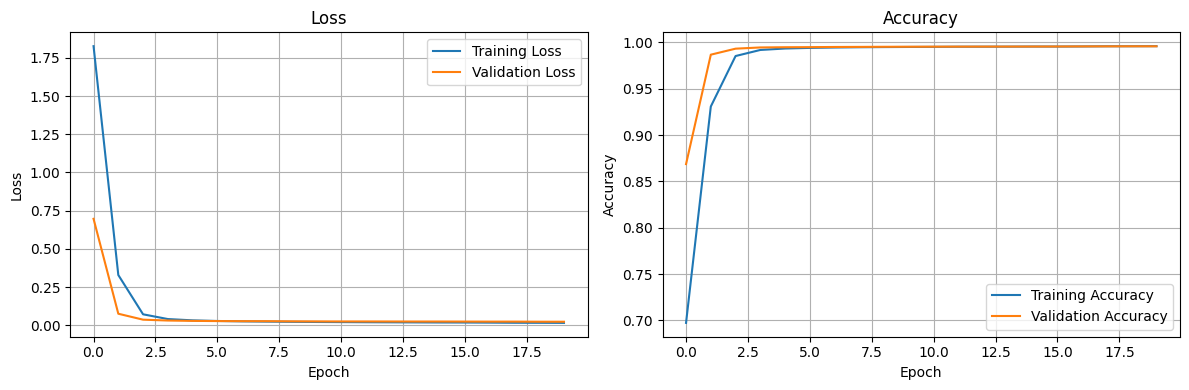

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/step - accuracy: 0.9958 - loss: 0.0236
Test Loss: 0.0234
Test Accuracy: 0.9957
Model saved to: strudel_model.keras


In [ ]:
import numpy as np
import json
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from tensorflow.keras import mixed_precision

#Enable mixed precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("Mixed precision enabled: float16")

#Config
class Config:
    # Data paths
    DATA_DIR = 'processed_data'
    MODEL_SAVE_PATH = 'strudel_model.keras'

    # Model hyperparameters
    VOCAB_SIZE = 5000
    EMBEDDING_DIM = 128
    LSTM_UNITS = 256
    DROPOUT_RATE = 0.2

    # Training hyperparameters
    BATCH_SIZE = 512
    EPOCHS = 20
    LEARNING_RATE = 0.002
    VALIDATION_SPLIT = 0.05
    TEST_SPLIT = 0.05

    # Generation parameters
    SEQUENCE_LENGTH = 50
    TEMPERATURE = 1.0

config = Config()

#Load processed data
X = np.load(f'{config.DATA_DIR}/X_train.npy')
y = np.load(f'{config.DATA_DIR}/y_train.npy')

with open(f'{config.DATA_DIR}/vocabulary.json', 'r') as f:
    vocabulary = json.load(f)

with open(f'{config.DATA_DIR}/reverse_vocab.json', 'r') as f:
    reverse_vocab = {int(k): v for k, v in json.load(f).items()}

print(f"Total sequences: {X.shape[0]}")
print(f"Vocabulary size: {len(vocabulary)}")

# Reshape y for training
y = y.reshape(y.shape[0], y.shape[1], 1)

#Shuffle and split into train/val/test
total_size = X.shape[0]
val_size = int(total_size * config.VALIDATION_SPLIT)
test_size = int(total_size * config.TEST_SPLIT)
train_size = total_size - val_size - test_size

indices = np.arange(total_size)
np.random.shuffle(indices)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

#Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.cache()
train_dataset = train_dataset.shuffle(10000, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(config.BATCH_SIZE, drop_remainder=True)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(config.BATCH_SIZE, drop_remainder=False)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print(f"Training batches: ~{len(list(train_dataset))}")
print(f"Validation batches: ~{len(list(val_dataset))}")
print(f"Test batches: ~{len(list(test_dataset))}")

#Build Model
def build_fast_model(vocab_size, embedding_dim, lstm_units, dropout_rate, seq_length):
    inputs = layers.Input(shape=(seq_length,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=False)(inputs)
    x = layers.Bidirectional(layers.LSTM(lstm_units, return_sequences=True, dropout=dropout_rate,
                    recurrent_dropout=0.0, use_cudnn=True))(x)
    x = layers.Dense(lstm_units, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(vocab_size, activation='softmax', dtype='float32')(x)
    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

model = build_fast_model(config.VOCAB_SIZE, config.EMBEDDING_DIM,
                         config.LSTM_UNITS, config.DROPOUT_RATE, config.SEQUENCE_LENGTH)

model.summary()

#Compile
optimizer = keras.optimizers.Adam(learning_rate=config.LEARNING_RATE, epsilon=1e-7)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=True)

#Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(config.MODEL_SAVE_PATH, save_best_only=True, monitor='val_loss',
                                    verbose=1, save_weights_only=False),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-4, verbose=1)
]

#Train

history = model.fit(train_dataset, validation_data=val_dataset, epochs=config.EPOCHS,
                    callbacks=callbacks, verbose=1)

#Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

#Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(test_dataset, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


print(f"Model saved to: {config.MODEL_SAVE_PATH}")


# Accuracy testing by masking random notes in the test data

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

MODEL_PATH = 'BiLSTM_model.keras'
BATCH_SIZE = 512
MASK_PROB = 0.15  # 15% of notes will be masked randomly

# Load trained model
model = keras.models.load_model(MODEL_PATH)

# Ensure y_test shape is right
if y_test.ndim == 3 and y_test.shape[-1] == 1:
    y_test = np.squeeze(y_test, axis=-1)

# Copy test data so we don’t destroy it
X_masked = np.copy(X_test)

# Randomly choose positions to mask
mask_positions = np.random.rand(*X_masked.shape) < MASK_PROB

# Optional: define a "mask token" (like 0, or vocab_size+1 if you added one)
MASK_TOKEN = 0
X_masked[mask_positions] = MASK_TOKEN

# Predict in batches
y_pred_probs = model.predict(X_masked, batch_size=BATCH_SIZE, verbose=1)
y_pred_int = np.argmax(y_pred_probs, axis=-1)

# Evaluate only at masked positions
masked_true = y_test[mask_positions]
masked_pred = y_pred_int[mask_positions]

accuracy = np.sum(masked_true == masked_pred) / len(masked_true)
print(f"\nMasked-note prediction accuracy: {accuracy*100:.2f}%")

# Show some random examples
sample_indices = np.random.choice(np.where(mask_positions.flatten())[0], size=5, replace=False)
print("\nSample masked predictions:")
for idx in sample_indices:
    seq_idx = idx // X_test.shape[1]
    pos = idx % X_test.shape[1]
    print(f"Seq {seq_idx}, Pos {pos}: True = {y_test[seq_idx, pos]}, Pred = {y_pred_int[seq_idx, pos]}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 79s 5s/step

Masked-note prediction accuracy: 90.38%

Sample masked predictions:
Seq 6107, Pos 25: True = 0, Pred = 0
Seq 1387, Pos 34: True = 0, Pred = 0
Seq 238, Pos 23: True = 401, Pred = 401
Seq 6002, Pos 29: True = 13, Pred = 13
Seq 6334, Pos 0: True = 0, Pred = 0


In [5]:
MODEL_PATH = 'BiLSTM_model.keras'
BATCH_SIZE = 512
MASK_PROB = 0.25# 40% of notes will be masked randomly

# Load trained model
model = keras.models.load_model(MODEL_PATH)

# Ensure y_test shape is right
if y_test.ndim == 3 and y_test.shape[-1] == 1:
    y_test = np.squeeze(y_test, axis=-1)

# Copy test data so we don’t destroy it
X_masked = np.copy(X_test)

# Randomly choose positions to mask
mask_positions = np.random.rand(*X_masked.shape) < MASK_PROB

# Optional: define a "mask token" (like 0, or vocab_size+1 if you added one)
MASK_TOKEN = 0
X_masked[mask_positions] = MASK_TOKEN

# Predict in batches
y_pred_probs = model.predict(X_masked, batch_size=BATCH_SIZE, verbose=1)
y_pred_int = np.argmax(y_pred_probs, axis=-1)

# Evaluate only at masked positions
masked_true = y_test[mask_positions]
masked_pred = y_pred_int[mask_positions]

accuracy = np.sum(masked_true == masked_pred) / len(masked_true)
print(f"\nMasked-note prediction accuracy: {accuracy*100:.2f}%")

# Show some random examples
sample_indices = np.random.choice(np.where(mask_positions.flatten())[0], size=5, replace=False)
print("\nSample masked predictions:")
for idx in sample_indices:
    seq_idx = idx // X_test.shape[1]
    pos = idx % X_test.shape[1]
    print(f"Seq {seq_idx}, Pos {pos}: True = {y_test[seq_idx, pos]}, Pred = {y_pred_int[seq_idx, pos]}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step

Masked-note prediction accuracy: 84.71%

Sample masked predictions:
Seq 6523, Pos 23: True = 2, Pred = 0
Seq 3386, Pos 20: True = 0, Pred = 0
Seq 6601, Pos 17: True = 0, Pred = 0
Seq 777, Pos 12: True = 0, Pred = 0
Seq 2315, Pos 32: True = 4345, Pred = 4345


# Text Generation

In [3]:
MODEL_PATH = "BiLSTM_model.keras"
DATA_DIR = "processed_data"

# Load the trained LSTM model
model = keras.models.load_model(MODEL_PATH)

# Load the vocabulary (token -> index)
with open(f"{DATA_DIR}/vocabulary.json", "r") as f:
    vocabulary = json.load(f)

# Load reverse vocabulary (index -> token)
with open(f"{DATA_DIR}/reverse_vocab.json", "r") as f:
    reverse_vocab = {int(k): v for k, v in json.load(f).items()}

SEQUENCE_LENGTH = 50  # Model input sequence length

# Sample the next token using temperature scaling
def sample_with_temperature(predictions, temperature=1.0):
    predictions = np.asarray(predictions).astype("float64")
    predictions = np.log(predictions + 1e-10) / temperature  # Scale logits
    exp_preds = np.exp(predictions)
    predictions = exp_preds / np.sum(exp_preds)  # Convert to probabilities
    probas = np.random.multinomial(1, predictions, 1)  # Random sample
    return np.argmax(probas)  # Return token index

# Main generation function
def generate_strudel_code(
    model, 
    seed_text=None, 
    max_tokens=200, 
    temperature=1.0,
    num_lines=4  # Stop after this many note blocks
):
    # Start sequence if no seed provided
    if seed_text is None:
        generated_tokens = [vocabulary["<START>"], vocabulary["<CPM:120/4>"]]
    else:
        # Convert seed text to token indices
        generated_tokens = [
            vocabulary.get(token, vocabulary["<PAD>"]) 
            for token in seed_text.split()
        ]

    for i in range(max_tokens):
        # Prepare input sequence of fixed length
        if len(generated_tokens) < SEQUENCE_LENGTH:
            padded = [vocabulary["<PAD>"]] * (SEQUENCE_LENGTH - len(generated_tokens))
            input_seq = padded + generated_tokens
        else:
            input_seq = generated_tokens[-SEQUENCE_LENGTH:]

        input_seq = np.array([input_seq])

        # Predict next-token probabilities
        predictions = model.predict(input_seq, verbose=0)
        next_token_probs = predictions[0, -1, :]

        # Sample the next token
        next_token_idx = sample_with_temperature(next_token_probs, temperature)
        generated_tokens.append(next_token_idx)

        # Stop after desired number of note blocks
        if reverse_vocab[next_token_idx] == "<SEP>":
            sep_count = sum(1 for t in generated_tokens if reverse_vocab[t] == "<SEP>")
            if sep_count >= num_lines:
                break

    # Convert token indices back to strings
    generated_text_tokens = [reverse_vocab.get(idx, "<UNK>") for idx in generated_tokens]
    return format_as_strudel(generated_text_tokens)

# Format generated tokens into Strudel code
def format_as_strudel(tokens):
    output = []
    current_line = []
    cpm_value = "120/4"  # Default CPM

    for token in tokens:
        if token.startswith("<CPM:"):
            cpm_value = token.replace("<CPM:", "").replace(">", "")
        elif token == "<START>":
            continue  # Skip start token
        elif token == "<SEP>":  # End of a note block
            if current_line:
                output.append(" ".join(current_line))
                current_line = []
            output.append(">`)")  
            output.append("$: note(`<")
        elif token == "<END>":  # End of a line
            if current_line:
                output.append(" ".join(current_line))
                current_line = []
        elif token not in ["<PAD>", "<UNK>"]:  # Ignore padding/unknown
            current_line.append(token)

    if current_line:
        output.append(" ".join(current_line))

    # Combine into final Strudel format
    code = f"setcpm({cpm_value})\n"
    code += "$: note(`<\n"
    code += "\n".join(output)
    if not output[-1].endswith(">`)"):
        code += "\n>`)"
    return code


# Generate and print music with different temperatures
for temp in [1.5, 1.7, 1.9]:
    print(f"\n Temperature: {temp}")
    generated = generate_strudel_code(
        model, 
        temperature=temp,
        max_tokens=150,
        num_lines=3
    )
    print(generated)
    print()

print("\n")



 Temperature: 1.5
setcpm(120/4)
$: note(`<
[g#2 - - e3 - - b3 - - - - f#3 - - e3 -] [c#2 - - g#1]
[e3,b3] [- - - c5] [- - - a4] [- d5]
>`)
$: note(`<
[- - - - - - - f4] a3 g#3
>`)
$: note(`<
[- - - g4] [a#2 - - - g#2 g#2 - a#2]
[[c2,c#3] [c2,c#3] [e2,c#3] c#3] [[d3,a3,d4] - - - - - - - - - - - - - - - - - - - - [d3,a3,d4] - - - - - - - - - - [d3,b3,d4] - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - [d3,a3,d4] - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - [d3,b3,d4] - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -]
>`)
$: note(`<
>`)


 Temperature: 1.7
setcpm(120/4)
$: note(`<
[[b1,f#2] f#2 [d2,f#2,f#3] [b1,f#2] [b1,f#2] f#2 [d2,f#2,f#3] f#2]
[[b1,f#2] f#2 [d2,f#2,f#3] [b1,f#2] [b1,f#2] f#2 [d2,f#2,f#3] [b1,f#2]] [g1 g1 d2 d2] [[a3,c4,e4] - [a3,c4,e4] [a3,c4,e4] - [a3,c4,e4] [a3,c4,e4] - [a3,c4,e4] - [a3,c4,e4] [a3,c4,e4] - [a3,c4,e4] [a3,c4,e4] -]
[a1 a1 - -] [g1 g1 c2 c2] [d2 d2 e2 f#2]
a3 c2 [a3,c#4,e4,g4] d4
>`)
$: note(`<
g#1 [d#4,g#4,b